### Compare simulations

Notebook to read in a number of `sww` files and compare (plot) stage time series and flow through cross section near Merimbula bridge.

First import important modules, set up graphics, and define two useful functions.

In [15]:
%load_ext autoreload
%autoreload 2

import project
import anuga
import pandas as pd
import glob

import numpy as np
import os
import matplotlib.pyplot as plt

%matplotlib inline
#%matplotlib ipympl

# Allow inline jshtml animations
from matplotlib import rc
rc('animation', html='jshtml')

def open_sww_file(swwfile: str, gauge_x: np.ndarray, gauge_y: np.ndarray, verbose: bool = False) -> tuple[anuga.SWW_plotter, list[int]]:
    """
    Open an SWW file and return the plotter object and gauge IDs.
    
    Args:
        swwfile: Path to the SWW file
        verbose: Whether to print debug information
        
    Returns:
        tuple containing:
            - splotter: SWW_plotter object
            - gauge_ids: list of triangle IDs for each gauge location
    """
    splotter = anuga.SWW_plotter(swwfile)

    #splotter.filename = swwfile

    starttime = splotter.starttime
    dt = pd.to_datetime(starttime, unit='s')
    if verbose:
        print(f'Start time: {dt}')

    # Convert to absolute coordinates
    xc = splotter.xc + splotter.xllcorner
    yc = splotter.yc + splotter.yllcorner

    gauge_ids = []
    for row in zip(gauge_x, gauge_y):
        tid = np.argmin((xc-row[0])**2 + (yc-row[1])**2)
        if verbose:
            print(f'Gauge at ({row[0]:.1f}, {row[1]:.1f}) assigned to triangle {tid}')
        gauge_ids.append(tid)

    return splotter, gauge_ids



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Check for sww files and set up the sww files to compare

In [16]:
#simulation, model_data_start = 'sept_2003', 265
simulation, model_data_start = 'sept_2004', 274

model_dir = f'../../model_data_{simulation}'

swwfiles = glob.glob(f'*{simulation}*.sww')
swwfiles

['template_sept_2004_10785_weeds_20260325_075946.sww',
 'template_sept_2004_43200_weeds_20260302_194933.sww']

Read specified sww files, create associated SWW_plotters, and read in gauge locations 

In [17]:
verbose = False

num_of_triangles = []
for swwfile in swwfiles:
    num_of_triangles.append(int(swwfile.split('_')[3]))

gauge_location = pd.read_csv(project.gauge_filename)
gauge_x = gauge_location['easting'].to_numpy()
gauge_y = gauge_location['northing'].to_numpy()

splotters = []
gauge_id_list = []

for n, swwfile in enumerate(swwfiles):
    splotter, gauge_ids = open_sww_file(swwfile, gauge_x, gauge_y, verbose=verbose)
    splotters.append(splotter)
    gauge_id_list.append(gauge_ids) 


# polyline at bridge
polyline = [[759205.0-10, 5912912+10],
            [759205.0+45, 5912912-30]]


polygon = [[759205.0-20, 5912912],  
           [759205.0+45, 5912912-40],
           [759205.0+55, 5912912-20],
           [759205.0+5, 5912912+40]]

Plot Stage and Mesh near Merimbula Bridge

760070.0 5912979.0
460


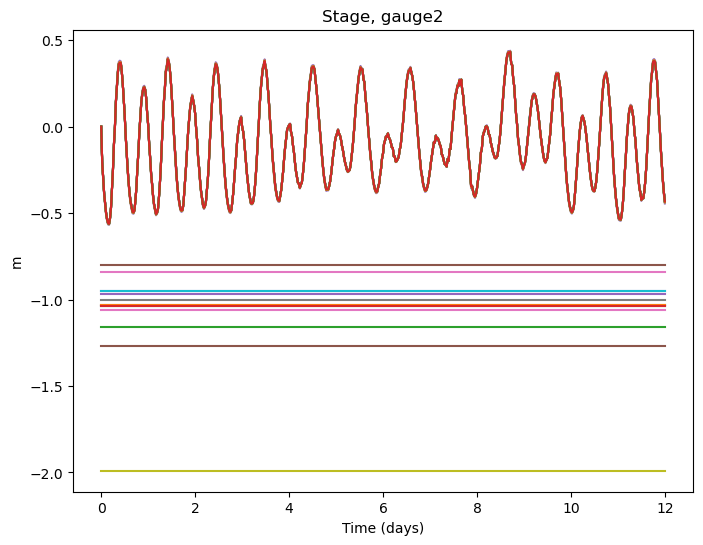

In [18]:
gid = 1
print(gauge_x[gid], gauge_y[gid])
splotter = splotters[0]
xc = splotter.xc + splotter.xllcorner
yc = splotter.yc + splotter.yllcorner
tids = np.where((xc-gauge_x[gid])**2 + (yc-gauge_y[gid])**2 < 50**2)[0]
print(tids[0])

fig, ax = plt.subplots(figsize=(8, 6))

t = splotter.time

for tid in tids: 
    ax.plot(t/3600/24, splotter.stage[:,tid], label=f"tid {tid}")

#print(splotter.elev.shape)
#print(tids)
for tid in tids:
    pass
    ax.plot(t/3600/24, np.ones_like(t)*splotter.elev[tid], label='elev')
                   
ax.set_xlabel('Time (days)')
ax.set_ylabel('m')
ax.set_title(f'Stage, {gauge_location["name"][gid]}')

#ax.set_xlim(3,4)
#ax.legend()
plt.show()

Gauge boundary at (760375.1, 5912233.1)
Gauge gauge2 at (760070.0, 5912979.0)
Gauge gauge3 at (759306.0, 5913042.0)
Gauge gauge4 at (759205.0, 5912912.0)
Gauge gauge5 at (759269.0, 5912751.0)
Gauge gauge6 at (757799.0, 5910529.0)
Gauge gauge7 at (757545.0, 5912703.0)
Gauge gauge8 at (756507.0, 5913260.0)
Triangles intersecting polygon: [  5 766 767 776]


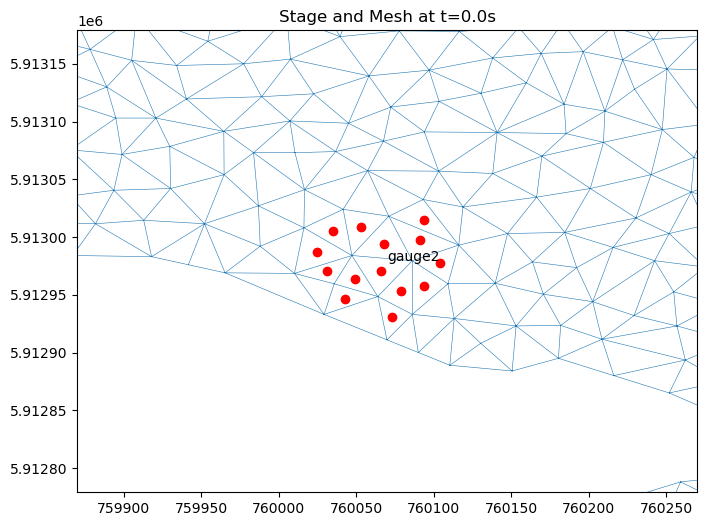

In [19]:
splotter = splotters[0]
tid = 0

fig, ax = plt.subplots(figsize=(8, 6))

# lines =ax.tripcolor(splotter.triang,
#               #facecolors = splotter.stage[tid,:],
#               facecolors = splotter.elev[:],
#               cmap='Greys_r',
#               vmin= -5,
#               vmax= 0.0
#               )
#fig.colorbar(lines, ax=ax, label='elevation (m)')

ax.triplot(splotter.triang, linewidth = 0.4)
ax.set_title(f"Stage and Mesh at t={splotter.time[tid]}s")
#ax.scatter(gauge_x, gauge_y, color='red')
for i in range(8):
#for i in range(3,4):
    ax.annotate(gauge_location['name'][i], [gauge_x[i], gauge_y[i]])
    print(f'Gauge {gauge_location["name"][i]} at ({gauge_x[i]}, {gauge_y[i]})')

triangle_ids = splotter.get_triangles_inside_polygon(polygon)
print(f'Triangles intersecting polygon: {triangle_ids}')

step = 200
#ax.set_xlim(759205-step, 759205.0+step)
#ax.set_ylim(5912912-step, 5912912+step)

ax.set_xlim(gauge_x[gid]-step, gauge_x[gid]+step)
ax.set_ylim(gauge_y[gid]-step, gauge_y[gid]+step)

# Plot the polyline
#ax.scatter([polyline[0][0], polyline[1][0]], [polyline[0][1], polyline[1][1]], color='blue')
#ax.plot([polyline[0][0], polyline[1][0]], [polyline[0][1], polyline[1][1]], color='blue')

ax.scatter(xc[tids], yc[tids], color='red')


# # Plot the polygon
# ax.plot([polygon[0][0], polygon[1][0], polygon[2][0], polygon[3][0], polygon[0][0]],
#          [polygon[0][1], polygon[1][1], polygon[2][1], polygon[3][1], polygon[0][1]], color='green')

# # Plot the centroids of the triangles intersecting the polygon
# for tid in triangle_ids:
#     xcentroid = splotter.xc[tid] + splotter.xllcorner
#     ycentroid = splotter.yc[tid] + splotter.yllcorner
#     ax.scatter(xcentroid, ycentroid, color='orange')
plt.show()
#plt.clf()


### Check starttime. 

Should be 22nd Oct 2003, or 30th Oct 2004, Australian Eastern Standard Time

In [20]:
dt_aest = pd.to_datetime(splotter.starttime, unit="s", utc=True).tz_convert(splotter.timezone)
print(dt_aest, splotter.timezone)

2004-09-30 00:00:00+10:00 Australia/Sydney


Text(0.5, 1.0, 'Elevation and Mesh at t=0.0s')

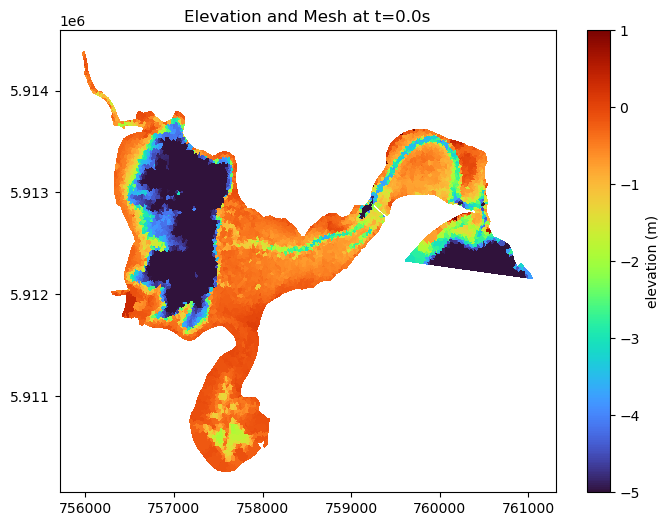

In [21]:
splotter = splotters[0]
tid = 0

fig, ax = plt.subplots(figsize=(8, 6))

lines = ax.tripcolor(splotter.triang,
              facecolors = splotter.elev[:],
              cmap='turbo',
              vmin= -5,
              vmax= 1.0
              )
#ax.triplot(splotter.triang, linewidth = 0.1)
fig.colorbar(lines, ax=ax, label='elevation (m)')
ax.set_title(f"Elevation and Mesh at t={splotter.time[tid]}s")
#ax.scatter(gauge_x, gauge_y, color='red')

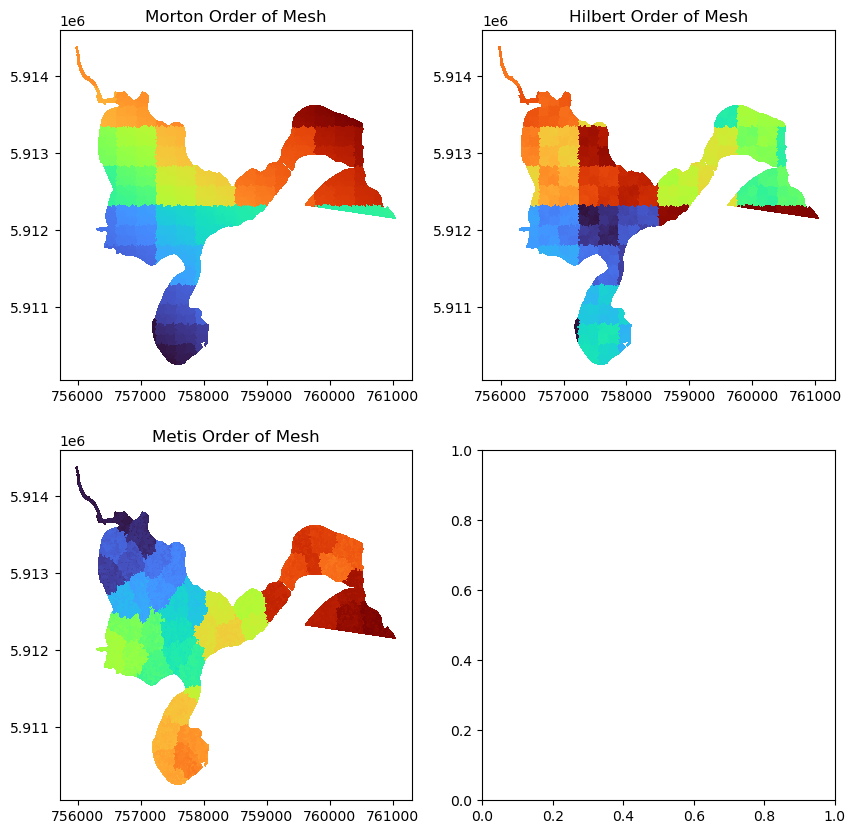

In [22]:
splotter = splotters[0]
tid = 0

from anuga.parallel.partitioning import morton_order_from_points, hilbert_order_from_points

from pymetis import part_mesh

points = np.stack((xc.ravel(), yc.ravel()), axis=1)

morton_order = morton_order_from_points(points)
inv_morton_order = np.empty_like(morton_order)
inv_morton_order[morton_order] = np.arange(len(morton_order))

hilbert_order = hilbert_order_from_points(points)
inv_hilbert_order = np.empty_like(morton_order)
inv_hilbert_order[hilbert_order] = np.arange(len(hilbert_order))

objval, epart, npart = part_mesh(40, splotter.triangles)
metis_order = np.argsort(epart, kind='mergesort')
inv_metis_order = np.empty_like(metis_order)
inv_metis_order[metis_order] = np.arange(len(metis_order))


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,10))

lines1 = ax1.tripcolor(splotter.triang, 
                     facecolors = inv_morton_order, 
                     cmap='turbo',
                    )
#fig.colorbar(lines1, ax=ax1, label='order')
ax1.set_title(f"Morton Order of Mesh")

lines2 = ax2.tripcolor(splotter.triang, 
                     facecolors = inv_hilbert_order, 
                     cmap='turbo',
                    )
#fig.colorbar(lines2, ax=ax2, label='order')
ax2.set_title(f"Hilbert Order of Mesh")

lines3 = ax3.tripcolor(splotter.triang, 
                     facecolors = inv_metis_order, 
                     cmap='turbo',
                    )
#fig.colorbar(lines3, ax=ax3, label='order')
ax3.set_title(f"Metis Order of Mesh")
pass



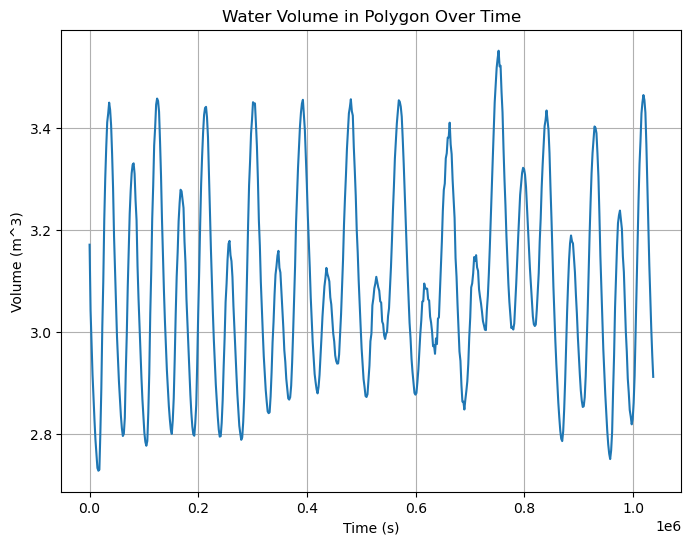

In [23]:
splotter = splotters[0]
volume = splotter.water_volume(per_unit_area=True, polygon=polygon)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(splotter.time, volume)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Volume (m^3)')
ax.set_title('Water Volume in Polygon Over Time')
ax.grid()
plt.show()

Compare flow through cross sesction

Extracting mesh intersections from line:
Cross-section intersects 4 triangles
Computing hydrograph
(759195.00, 5912922.00) - (759250.00, 5912882.00)
Done: 577 timesteps, Q range [-105, 161] m^3/s
Reading from template_sept_2004_43200_weeds_20260302_194933.sww
    building mesh from sww file template_sept_2004_43200_weeds_20260302_194933.sww
Extracting mesh intersections from line:
Cross-section intersects 8 triangles
Computing hydrograph
(759195.00, 5912922.00) - (759250.00, 5912882.00)
Done: 577 timesteps, Q range [-95, 138] m^3/s
Note: no measured data available


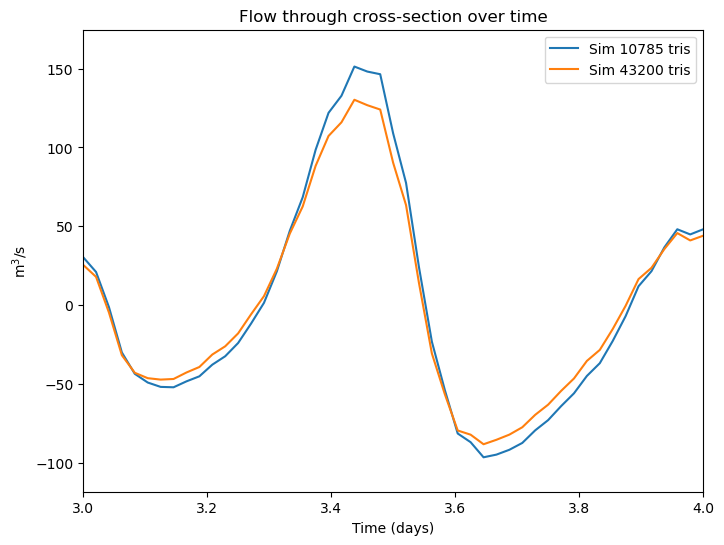

In [24]:
verbose = False

fig, ax = plt.subplots(figsize=(8, 6))

for n, splotter in enumerate(splotters):
    t, Q = splotter.get_flow_through_cross_section(polyline, verbose=True) 
    ax.plot(t/3600/24, Q, label=f'Sim {num_of_triangles[n]} tris')
    

    data = np.column_stack((t, Q))  # shape (N, 2)
    filename = f"cross_section_flow_{num_of_triangles[n]}_tris.csv"
    np.savetxt(filename, data,
               delimiter=",",
               header="time,Q",
               comments="")
                   
ax.set_xlabel('Time (days)')
ax.set_ylabel('m$^3$/s')
ax.set_title('Flow through cross-section over time')



if simulation == 'sept_2003':
    filename = anuga.join(model_dir,'gauge4_discharge.txt')
    flow = pd.read_csv(filename, header=None, sep=r"\s+")
    #print(flow)
    
    flow.columns = ['time', 'measured']
    flow['time'] = flow['time'] /24.0 + 3.0 # convert time to days 25th Sept 2003 was at 3 days in the model time
    
    
    ax.plot(flow['time'], flow['measured'], label='Measured')
else:
    print('Note: no measured data available')

ax.set_xlim(3,4)
ax.legend()
plt.show()

Compare stage time series at one gauge station

Simulation 0 has 577 timesteps and 10785 triangles.
Simulation 1 has 577 timesteps and 43200 triangles.


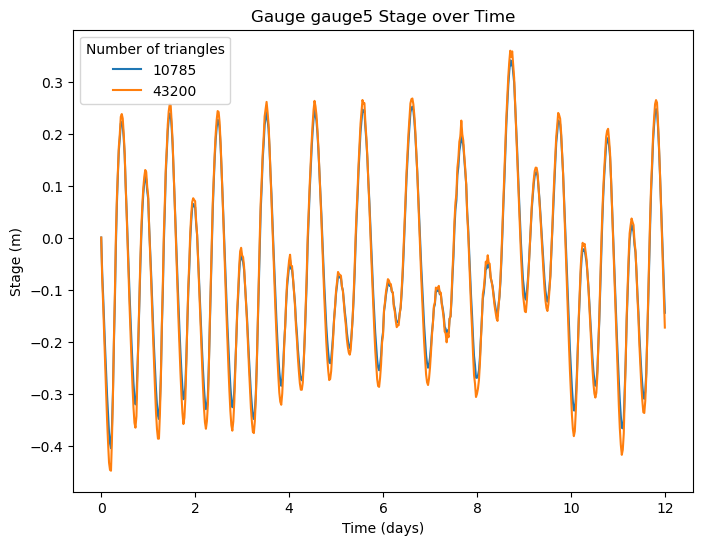

In [25]:
gid = 4  # gauge id to plot

fig, ax = plt.subplots(figsize=(8, 6))

for n,splotter in enumerate(splotters):
    print(f'Simulation {n} has {splotter.stage.shape[0]} timesteps and {splotter.stage.shape[1]} triangles.')
    ax.plot(splotter.time/3600/24, splotter.stage[:,gauge_id_list[n][gid]], label=num_of_triangles[n])

ax.legend(title='Number of triangles')
ax.set_title(f'Gauge {gauge_location["name"][gid]} Stage over Time')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Stage (m)')
plt.show()

Compare simulation results with measured stage data

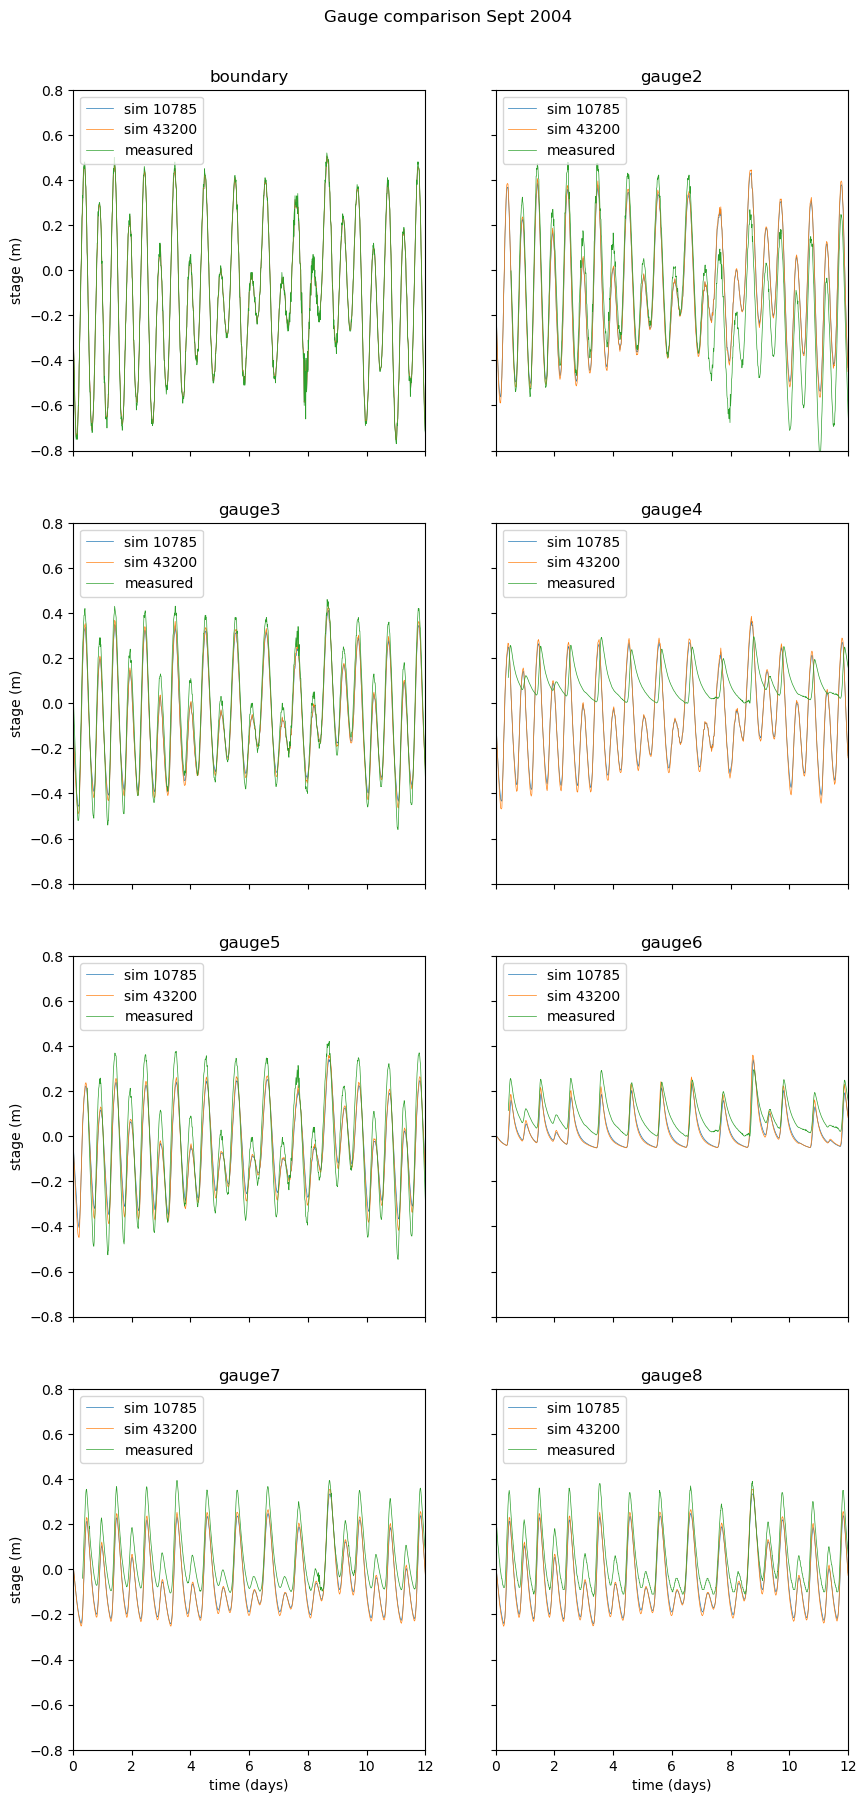

In [26]:
sites = []

#for row in gauge_location.iterrows():

for index, row in gauge_location.iterrows():
    filename = anuga.join(model_dir,row['name']+'.txt')

    if row['name'] == 'gauge4' and simulation == 'sept_2003':
        print(f"Gauge 4 measured stage data is missing {row['name']}")
        site = None
    else:
        site = pd.read_fwf(filename, header=None)
        site.columns = ['time', 'measured']
        site['time'] = site['time'] - model_data_start # 265

    sites.append(site)
        

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(4, 2, figsize=(10,20), sharex=True, sharey=True)


for i, ax in enumerate([ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]):

    ax.set_title(gauge_location['name'][i])
    for n, (splotter, gauge_ids) in enumerate(zip(splotters, gauge_id_list)): 
        #pass
        ax.plot(splotter.time/3600/24, 
                splotter.stage[:,gauge_ids[i]], 
                label='sim '+str(num_of_triangles[n]), 
                linewidth=0.5)
    

    if gauge_location['name'][i] == 'gauge4' and simulation == 'sept_2003':
        pass
    else:
        sites[i].plot('time','measured', ax=ax, label='measured', linewidth=0.5)

    ax.legend(loc='upper left')
    ax.set_xlim(0.0, 12.0)
    ax.set_ylim(-0.8, 0.8)
    ax.set_xlabel('time (days)')
    ax.set_ylabel('stage (m)')

fig.suptitle(f'Gauge comparison {simulation.replace('_',' ').title()}')
fig.subplots_adjust(top=0.94)
#plt.show()
fig.savefig(f'gauge_comparison_{simulation}.png')    


In [ ]:
# from anuga.file_conversion.sww2dem import sww2dem, sww2dem_batch

# sww2dem(swwfiles[0], name_out= 'domain2.asc', quantity='stage', verbose=True)

In [ ]:
# sww2dem_batch(swwfiles[0], quantities=['stage', 'depth'], format='asc', verbose=True)